In [1]:
## use lasso regression to choose the best features to run into the model most of the data has high colinearity that correlates on variable with another

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold


In [2]:
df=pd.read_csv('synthetic_output_data.csv').drop("address", axis=1)

# Select numeric columns for clustering
# Segregating the Feature and Target
X = df.drop("trading_pnl", axis=1).values
y = df["trading_pnl"].values



# # Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Shape of Train Features: {}".format(X_train.shape))
print("Shape of Test Features: {}".format(X_test.shape))
print("Shape of Train Target: {}".format(y_train.shape))
print("Shape of Test Target: {}".format(y_test.shape))

Shape of Train Features: (80000, 9)
Shape of Test Features: (20000, 9)
Shape of Train Target: (80000,)
Shape of Test Target: (20000,)


In [3]:
# parameters to be tested on GridSearchCV
params = {"alpha":np.arange(0.00001, 10, 500)}

# Number of Folds and adding the random state for replication
kf=KFold(n_splits=5,shuffle=True, random_state=42)

# Initializing the Model
lasso = Lasso()

# GridSearchCV with model, params and folds.
lasso_cv=GridSearchCV(lasso, param_grid=params, cv=kf)
lasso_cv.fit(X, y)
print("Best Params {}".format(lasso_cv.best_params_))

Best Params {'alpha': np.float64(1e-05)}


In [4]:
names=df.drop("trading_pnl", axis=1).columns
print("Column Names: {}".format(names.values))

Column Names: ['nft_pnl' 'nft_pl_ratio' 'nft_winrate' 'trading_pnl_ratio'
 'trade_winrate' 'liquidity_ratio' 'trading_frequency' 'nft_sales_rate'
 'prop_success_trades']


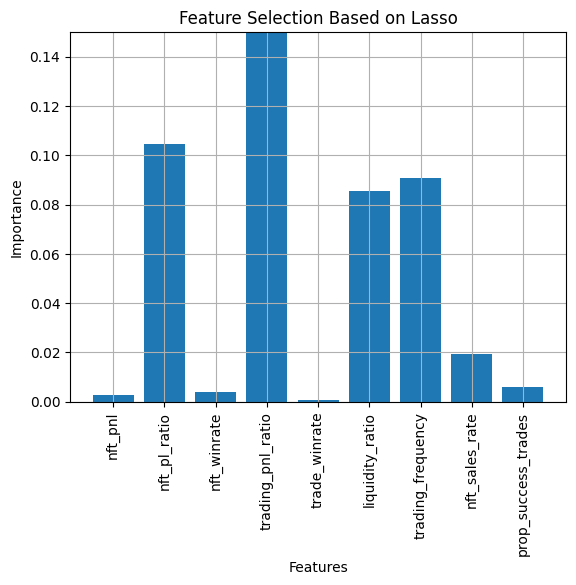

In [5]:
# calling the model with the best parameter
lasso1 = Lasso(alpha=0.00001)
lasso1.fit(X_train, y_train)

# Using np.abs() to make coefficients positive.  
lasso1_coef = np.abs(lasso1.coef_)

# plotting the Column Names and Importance of Columns. 
plt.bar(names, lasso1_coef)
plt.xticks(rotation=90)
plt.grid()
plt.title("Feature Selection Based on Lasso")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.ylim(0, 0.15)
plt.show()

In [6]:
# Subsetting the features which has more than 0.001 importance. since we are focusing on high speed transactions
feature_subset=np.array(names)[lasso1_coef>0.01]
print("Selected Feature Columns: {}".format(feature_subset))

# Adding the target to the list of feaatures. 
new_features=np.append(feature_subset, "trading_pnl")
print("Selected Columns: {}".format(new_features))



Selected Feature Columns: ['nft_pl_ratio' 'trading_pnl_ratio' 'liquidity_ratio' 'trading_frequency'
 'nft_sales_rate']
Selected Columns: ['nft_pl_ratio' 'trading_pnl_ratio' 'liquidity_ratio' 'trading_frequency'
 'nft_sales_rate' 'trading_pnl']


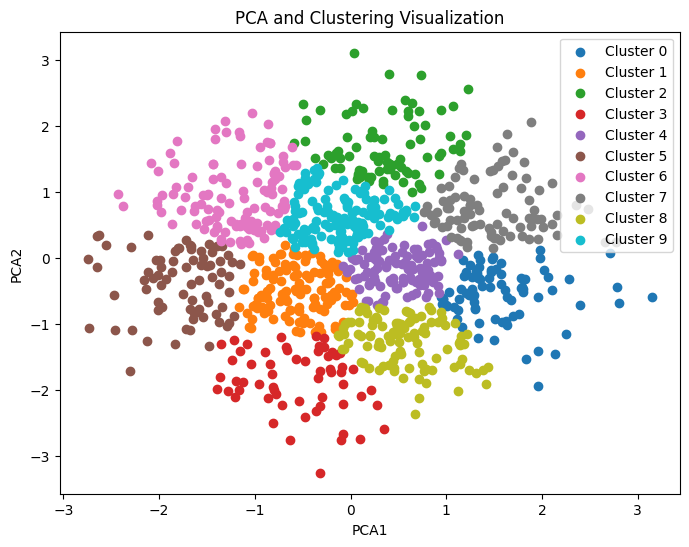

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df_new = df[new_features][1:1000]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_new) 
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Perform k-means clustering
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# pca_data[:,0]

df_new['PCA1'] = pca_data[:, 0]

df_new['PCA2'] = pca_data[:, 1]
df_new['Cluster'] = clusters

# # Visualize the clusters
plt.figure(figsize=(8, 6))
for cluster in set(clusters):
    cluster_points = df_new[df_new['Cluster'] == cluster]
    plt.scatter(cluster_points['PCA1'], cluster_points['PCA2'], label=f'Cluster {cluster}')

plt.title('PCA and Clustering Visualization')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

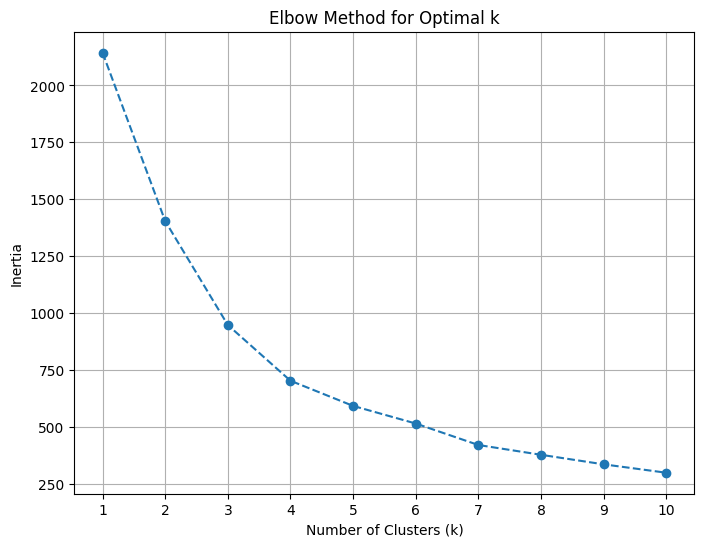

In [8]:
k_values = range(1, 11)
inertia_values = []

# Compute inertia for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error 
rf_dataframe= df_new.drop(columns=['PCA1','PCA2','Cluster'])



In [10]:
X = rf_dataframe.drop(columns=['trading_pnl'])  # Assuming 'trading_pnl' is the target
y = rf_dataframe['trading_pnl']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 33.60107535470839


In [11]:
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(importance_df)


             Feature  Importance
1  trading_pnl_ratio    0.205378
0       nft_pl_ratio    0.205097
4     nft_sales_rate    0.203742
3  trading_frequency    0.196456
2    liquidity_ratio    0.189326


In [12]:
from sklearn.tree import plot_tree

# Visualize one of the trees in the forest
# plt.figure(figsize=(20, 10))
# plot_tree(rf.estimators_[0], feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
# plt.title('Random Forest Decision Tree')
# plt.show()


In [24]:
import numpy as np

# Example observation (replace with your own values, matching the feature order in X)

example_obs= {
    'nft_pl_ratio': 0.8,
    'trading_pnl_ratio':  0.7,
    'liquidity_ratio': 0.6,
    'trading_frequency': 1.2,
    'nft_sales_rate': -0.3
}
feature_order = ['nft_pl_ratio', 'trading_pnl_ratio', 'liquidity_ratio', 'trading_frequency', 'nft_sales_rate']

# Convert dictionary to a properly ordered NumPy array
ordered_values = [example_obs[feature] for feature in feature_order]
new_observation = np.array(ordered_values).reshape(1, -1)  # Shape (1, num_features)


# Make prediction
prediction = rf.predict(new_observation)
print("Your Expected Profit and Loss Trade:", prediction[0])


Your Expected Profit and Loss Trade: 0.12827293966483339


d:\GithubRepos\ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
